# Question 3a)

Error unbounded. Plots not shown.
FEM method with theta=0.5 converges: Convergence rate in discrete $L^2$ norm with respect to time step $k$: 1.9611430075128509


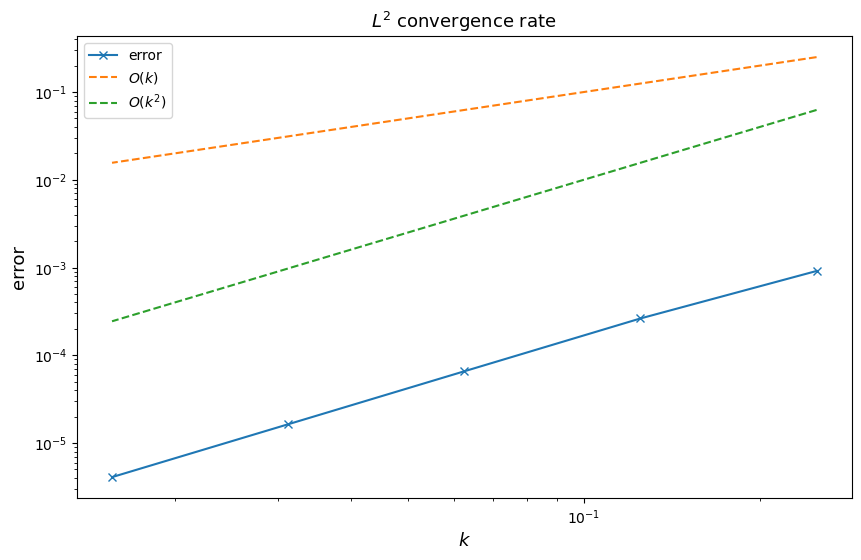

FEM method with theta=1 converges: Convergence rate in discrete $L^2$ norm with respect to time step $k$: 0.9012711498901023


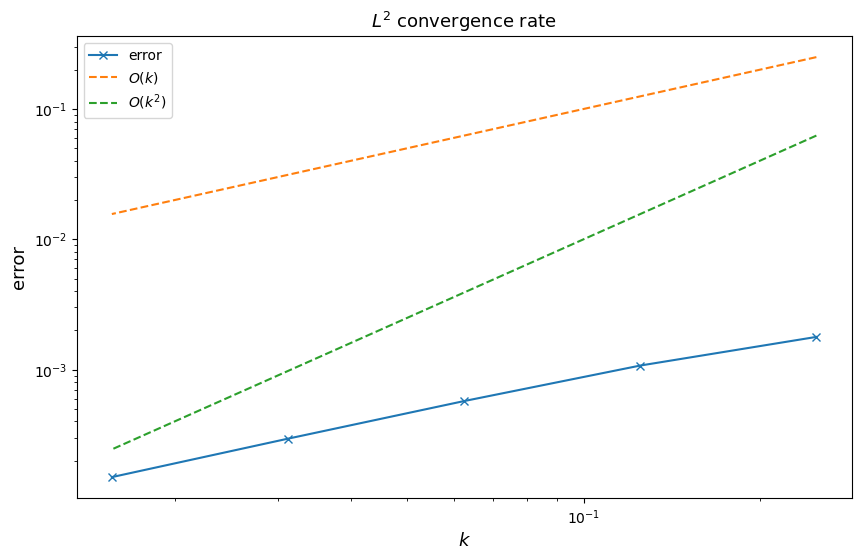

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as lin
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def kappa_integral(x,y):
    p = (y - x)*(1 + 0.5*(x + y))
    return p

def build_massMatrix(N):
    # todo 3 b)
    h = 1/(N + 1)
    diagonal = np.ones(N)
    lower = np.ones(N - 1)
    upper = np.ones(N - 1)
    mass_matrix = (h/6) * sp.diags([lower, 4*diagonal, upper], offsets = [-1, 0, 1])
    return mass_matrix.toarray()


def build_rigidityMatrix(N):
    # todo 3 b)
    # Be careful with the indices!
    # kappa_integral could be helpful here
    
    M = np.zeros((N,N))
    h = 1/(N + 1)
    # The case of i=j
    for i in range(N):
        M[i,i] = (1 / (h**2)) * kappa_integral(i*h, (i+2)*h)

    # The case of i-j=1
    for i in range(1,N):
        M[i, i-1] = -(1 / (h**2)) * kappa_integral(i*h, (i+1)*h)


    # The case of j-i=1
    for i in range(N-1):
        M[i, i+1] = -(1 / (h**2)) * kappa_integral((i+1)*h, (i+2)*h)

    return M


def f(t,x):
    a = ((x + 1)*(np.pi**2) - 1) * np.exp(-t) * np.sin(np.pi * x)
    b = np.pi * np.exp(-t) * np.cos(np.pi*x)
    return a - b
    

def initial_value(x):
    return np.sin(np.pi*x)


def exact_solution_at_1(x):
    return np.exp(-1)*np.sin(np.pi*x)


def build_F(t,N):
    F = np.ones(N)
    h = 1/(N + 1)
    for i in range(N):
        a = f(t, ((i + 1)*h) - h/2)
        b = f(t, (i + 1)*h)
        c = f(t, ((i + 1)*h) + h/2)
        F[i] = (h/3)*(a + b + c)

    return F

def FEM_theta(N,M,theta):
    # get auxiliary variables
    h = 1/(N+1)
    k = 1/M

    # get u^0
    x_grid = np.linspace(h, N*h, N)
    um = initial_value(x_grid)

    #getting auxialiary matrices
    mass_matrix = build_massMatrix(N)
    A = build_rigidityMatrix(N)
    B = mass_matrix + k*theta*A

    # iterate
    j = 0
    for j in range(M):
        F_theta = theta*build_F((j+1)*k, N) + (1 - theta)*build_F(j*k, N)

        rhs = (mass_matrix - k*(1 - theta)* A) @ um + k*F_theta

        um = lin.solve(B, rhs)

    # to get back approximate solution, we have to get back the hat functions

    x_grid = np.linspace(h, N*h, N)
    sol = []
    for x in x_grid:
        val = 0
        for j in range(N):
            val += um[j]*max(0, 1 - (1/h)*np.abs(x - (j+1)*h))
        sol.append(val)
    return np.array(sol)



#### error analysis ####
nb_samples = 5
N = np.array([(2**l) - 1 for l in range(2, 7)], dtype=int)
M = np.array([(2**l) for l in range(2, 7)], dtype=int)
theta_vals = [0.3, 0.5, 1]


#### Do not change any code below! ####
for theta in theta_vals:
   l2error = np.zeros(nb_samples) 
   k =  1 / M

   try:
      for i in range(nb_samples):
         l2error[i] = (1 / (N[i]+1)) ** (1 / 2) * lin.norm(exact_solution_at_1((1/(N[i]+1))*(np.arange(N[i])+1)) - FEM_theta(N[i], M[i],theta), ord=2)
         if np.isnan(l2error[i])==True:
             raise Exception("Error unbounded. Plots not shown.")
      conv_rate = np.polyfit(np.log(k), np.log(l2error), deg=1)
      if conv_rate[0]<0:
          raise Exception("Error unbounded. Plots not shown.")
      print(f"FEM method with theta={theta} converges: Convergence rate in discrete $L^2$ norm with respect to time step $k$: {conv_rate[0]}")
      plt.figure(figsize=[10, 6])
      plt.loglog(k, l2error, '-x', label='error')
      plt.loglog(k, k, '--', label='$O(k)$')
      plt.loglog(k, k**2, '--', label='$O(k^2)$')
      plt.title('$L^2$ convergence rate', fontsize=13)
      plt.xlabel('$k$', fontsize=13)
      plt.ylabel('error', fontsize=13)
      plt.legend()
      plt.plot()
      plt.show()
   except Exception as e:
      print(e)


C:\Users\hugob\AppData\Local\Temp\ipykernel_38592\3321604922.py:89: RuntimeWarning: invalid value encountered in matmul
  rhs = (mass_matrix - k*(1 - theta)* A) @ um + k*F_theta


Error unbounded. Plots not shown.
FEM method with theta=0.5 converges: Convergence rate in discrete $L^2$ norm with respect to time step $k$: 1.0140334164924607


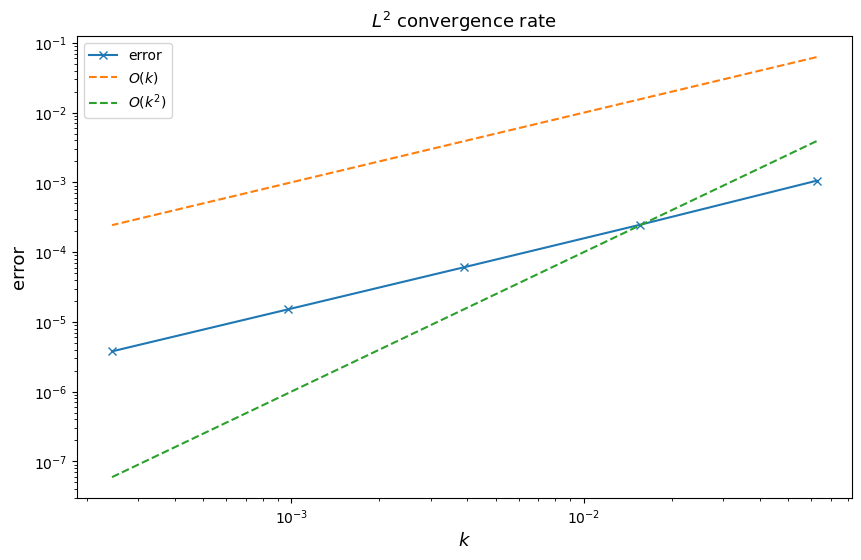

FEM method with theta=1 converges: Convergence rate in discrete $L^2$ norm with respect to time step $k$: 1.0097124787268716


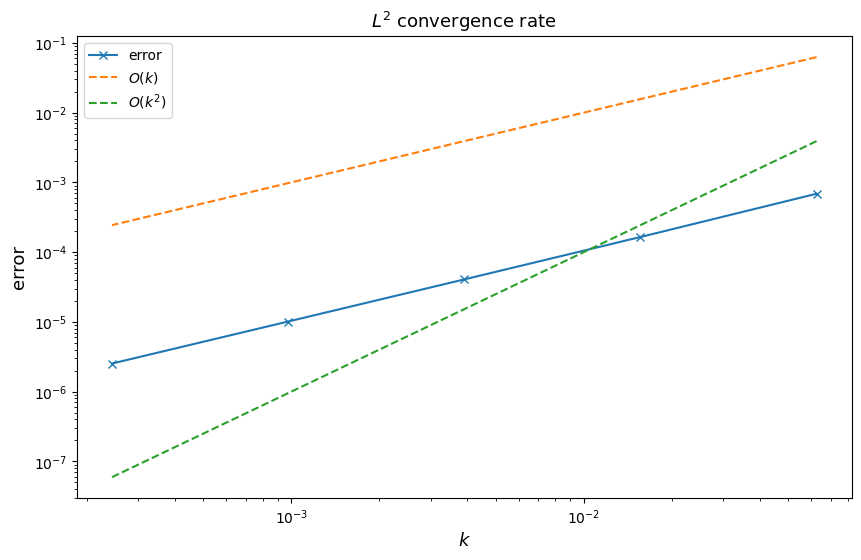

In [22]:
#### error analysis ####
nb_samples = 5
N = np.array([(2**l) - 1 for l in range(2, 7)], dtype=int)
M = np.array([(4**l) for l in range(2, 7)], dtype=int)
theta_vals = [0.3, 0.5, 1]

#### Do not change any code below! ####
for theta in theta_vals:
   l2error = np.zeros(nb_samples) 
   k =  1 / M

   try:
      for i in range(nb_samples):
         l2error[i] = (1 / (N[i]+1)) ** (1 / 2) * lin.norm(exact_solution_at_1((1/(N[i]+1))*(np.arange(N[i])+1)) - FEM_theta(N[i], M[i],theta), ord=2)
         if np.isnan(l2error[i])==True:
             raise Exception("Error unbounded. Plots not shown.")
      conv_rate = np.polyfit(np.log(k), np.log(l2error), deg=1)
      if conv_rate[0]<0:
          raise Exception("Error unbounded. Plots not shown.")
      print(f"FEM method with theta={theta} converges: Convergence rate in discrete $L^2$ norm with respect to time step $k$: {conv_rate[0]}")
      plt.figure(figsize=[10, 6])
      plt.loglog(k, l2error, '-x', label='error')
      plt.loglog(k, k, '--', label='$O(k)$')
      plt.loglog(k, k**2, '--', label='$O(k^2)$')
      plt.title('$L^2$ convergence rate', fontsize=13)
      plt.xlabel('$k$', fontsize=13)
      plt.ylabel('error', fontsize=13)
      plt.legend()
      plt.plot()
      plt.show()
   except Exception as e:
      print(e)